In [4]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.4 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.3 MB 2.6 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.3 MB 3.8 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 5.3 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 6.0 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.8 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -- ------------------------------------- 2.1/37.3 MB 10.7 MB/s eta 0:00:04
   ----- ---------------------------------- 4.7/37.3 MB 11.1 MB/s eta 0:00:03
   ----- -----------------------------

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
df = pd.read_csv("../data/processed/cleaned_medical_appointments.csv")
df.head()

,gender,age,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,waiting_days,...,neighbourhood_SANTOS REIS,neighbourhood_SEGURANÇA DO LAR,neighbourhood_SOLON BORGES,neighbourhood_SÃO BENEDITO,neighbourhood_SÃO CRISTÓVÃO,neighbourhood_SÃO JOSÉ,neighbourhood_SÃO PEDRO,neighbourhood_TABUAZEIRO,neighbourhood_UNIVERSITÁRIO,neighbourhood_VILA RUBIM
0,0,62,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,56,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,62,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,8,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,56,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(110522, 96)

In [6]:
X = df.drop('no_show', axis=1)

y = df['no_show']

In [7]:
print(X.shape)
print(y.shape)

(110522, 95)
(110522,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(88417, 95)
(22105, 95)
(88417,)
(22105,)


In [10]:
model = LogisticRegression(max_iter=1000)

In [11]:
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [12]:
y_pred = model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8000904772675865


In [14]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.3628691983122363


In [15]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.01975195222783647


In [16]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.03746460466129384


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17751
           1       0.36      0.02      0.04      4354

    accuracy                           0.80     22105
   macro avg       0.58      0.51      0.46     22105
weighted avg       0.72      0.80      0.72     22105



In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[17600   151]
 [ 4268    86]]


In [19]:
balanced_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

In [20]:
balanced_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [21]:
balanced_pred = balanced_model.predict(X_test)

In [22]:
print(classification_report(y_test, balanced_pred))

              precision    recall  f1-score   support

           0       0.87      0.68      0.76     17751
           1       0.31      0.59      0.40      4354

    accuracy                           0.66     22105
   macro avg       0.59      0.63      0.58     22105
weighted avg       0.76      0.66      0.69     22105



In [23]:
print(confusion_matrix(y_test, balanced_pred))

[[12028  5723]
 [ 1803  2551]]


In [24]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [26]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [27]:
rf_pred = rf_model.predict(X_test)

In [28]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.95      0.88     17751
           1       0.46      0.17      0.25      4354

    accuracy                           0.80     22105
   macro avg       0.64      0.56      0.57     22105
weighted avg       0.75      0.80      0.76     22105



In [29]:
print(confusion_matrix(y_test, rf_pred))

[[16889   862]
 [ 3617   737]]


In [30]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

In [31]:
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [32]:
from sklearn.metrics import accuracy_score
rf_tuned_pred = rf_tuned.predict(X_test)

accuracy = accuracy_score(y_test, rf_tuned_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.5655733996833295
Accuracy (%): 56.557339968332954


In [33]:
import joblib

model = joblib.load("../models/medical_no_show_model.pkl")
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv(
    "../models/feature_importance.csv",
    index=False
)

feature_importance.head()

,Feature,Importance
8,waiting_days,0.639559
7,sms_received,0.104780
1,age,0.090104
9,scheduled_hour,0.051127
3,hypertension,0.011546


In [34]:
import os

os.path.exists("../models/feature_importance.csv")

True

In [35]:
rf_tuned_pred = rf_tuned.predict(X_test)

In [36]:
print(classification_report(y_test, rf_tuned_pred))

              precision    recall  f1-score   support

           0       0.93      0.49      0.65     17751
           1       0.29      0.86      0.44      4354

    accuracy                           0.57     22105
   macro avg       0.61      0.68      0.54     22105
weighted avg       0.81      0.57      0.61     22105



In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print(confusion_matrix(y_test, rf_tuned_pred))

[[8771 8980]
 [ 623 3731]]


In [38]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
8,waiting_days,0.639559
7,sms_received,0.104780
1,age,0.090104
9,scheduled_hour,0.051127
3,hypertension,0.011546
2,scholarship,0.008713
0,gender,0.007771
13,appointment_weekday_Tuesday,0.005452
10,appointment_weekday_Monday,0.004869
14,appointment_weekday_Wednesday,0.004586


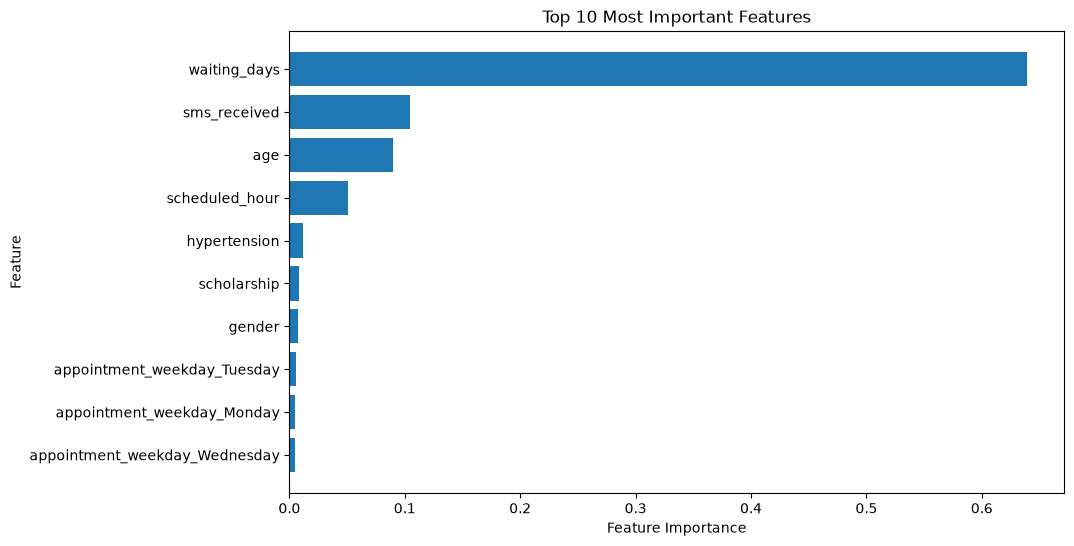

In [39]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

In [40]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Balanced)",
        "Random Forest",
        "Random Forest (Tuned)"
    ],
    "Accuracy": [0.80, 0.66, 0.80, 0.57],
    "Precision": [0.36, 0.31, 0.46, 0.29],
    "Recall": [0.02, 0.59, 0.17, 0.86],
    "F1-Score": [0.04, 0.40, 0.25, 0.44]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.80,0.36,0.02,0.04
1,Logistic Regression (Balanced),0.66,0.31,0.59,0.40
2,Random Forest,0.80,0.46,0.17,0.25
3,Random Forest (Tuned),0.57,0.29,0.86,0.44


In [41]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

print("Accuracy:", accuracy_score(y_test, ada_pred))
print(classification_report(y_test, ada_pred))

Accuracy: 0.8029857498303551
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     17751
           1       0.43      0.00      0.00      4354

    accuracy                           0.80     22105
   macro avg       0.62      0.50      0.45     22105
weighted avg       0.73      0.80      0.72     22105



In [42]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

hist_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=10,
    max_iter=200,
    random_state=42
)

hist_model.fit(X_train, y_train)

hist_pred = hist_model.predict(X_test)

print("HistGradientBoosting Accuracy:", accuracy_score(y_test, hist_pred))
print(classification_report(y_test, hist_pred))

HistGradientBoosting Accuracy: 0.8042976702103597
              precision    recall  f1-score   support

           0       0.81      0.99      0.89     17751
           1       0.56      0.03      0.06      4354

    accuracy                           0.80     22105
   macro avg       0.68      0.51      0.48     22105
weighted avg       0.76      0.80      0.73     22105



In [43]:
!pip install xgboost

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [45]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.8043429088441529
              precision    recall  f1-score   support

           0       0.81      0.99      0.89     17751
           1       0.55      0.04      0.07      4354

    accuracy                           0.80     22105
   macro avg       0.68      0.52      0.48     22105
weighted avg       0.76      0.80      0.73     22105



In [46]:
from collections import Counter

print(Counter(y_train))

Counter({0: 70457, 1: 17960})


In [47]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_balanced = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3.9,
    random_state=42,
    eval_metric="logloss"
)

xgb_balanced.fit(X_train, y_train)

pred = xgb_balanced.predict(X_test)

print("Balanced XGBoost Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Balanced XGBoost Accuracy: 0.6069215109703687
              precision    recall  f1-score   support

           0       0.92      0.56      0.69     17751
           1       0.31      0.81      0.45      4354

    accuracy                           0.61     22105
   macro avg       0.62      0.68      0.57     22105
weighted avg       0.80      0.61      0.65     22105



In [48]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
estimators = [
    ('rf', rf_tuned),
    ('ada', ada),
    ('xgb', xgb_model)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

In [57]:
import joblib

In [63]:
joblib.dump(rf_tuned, "../models/medical_no_show_model.pkl")
joblib.dump(list(X_train.columns), "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

In [59]:
import os

os.listdir("../models")

['.ipynb_checkpoints',
 'feature_columns.pkl',
 'feature_importance.csv',
 'medical_no_show_model.pkl']

In [60]:
model = joblib.load("../models/medical_no_show_model.pkl")
feature_columns = joblib.load("../models/feature_columns.pkl")

feature_importance = pd.read_csv("../models/feature_importance.csv")

In [61]:
print(feature_importance.head())

          Feature  Importance
0    waiting_days    0.639559
1    sms_received    0.104780
2             age    0.090104
3  scheduled_hour    0.051127
4    hypertension    0.011546
